# 03 — Classifier Comparison on Hybrid TF-IDF + SEC-BERT

**Goal:** Use the best embedding from Notebook 02 (Hybrid TF-IDF + SEC-BERT, F1=0.845) and compare 5 classifiers.

## Workflow
1. Rebuild Hybrid features: TF-IDF (500 features) + SEC-BERT (768 dims) → concatenated dense matrix
2. Compare 5 classifiers on the same train/test split
3. Evaluate with fraud-relevant metrics: **F1**, **Recall**, **ROC-AUC**
4. Validate with 5-fold cross-validation
5. Select and save the final model

> ⚠️ **Note:** Naive Bayes requires non-negative sparse input — it is **not compatible** with hybrid dense features.  
> It is included here using the TF-IDF portion only, clearly flagged as a partial comparison.

## 0. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

plt.style.use("ggplot")

FILE_PATH = r"C:/Users/user/Documents/data_science_bootcamp_challenges_project/capstone_project/amit_kedia_dataset.csv"
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TFIDF_FEATURES = 500   # matches NB02v2 hybrid config
BATCH_SIZE = 8

print(f"Device: {DEVICE}")
print(f"Embedding: Hybrid TF-IDF ({TFIDF_FEATURES} features) + SEC-BERT (768 dims)")

Device: cpu
Embedding: Hybrid TF-IDF (500 features) + SEC-BERT (768 dims)


## 1. Load and preprocess the dataset

In [2]:
df = pd.read_csv(FILE_PATH).drop_duplicates().reset_index(drop=True)

def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Fillings"].astype(str).apply(clean_text)
df["target"] = df["Fraud"].map({"no": 0, "yes": 1})

X_text = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Total rows  : {len(df)}")
print(f"Train: {len(X_train_text)} | Test: {len(X_test_text)}")
print(f"Fraud rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Total rows  : 170
Train: 136 | Test: 34
Fraud rate — Train: 50.00% | Test: 50.00%


## 2. Build Hybrid Features

The hybrid combines:
- **TF-IDF** (500 features, unigrams + bigrams): captures fraud-specific lexical patterns
- **SEC-BERT** (`nlpaueb/sec-bert-base`, frozen, CLS token): captures filing-specific semantic context

Both parts are L2-normalised before concatenation so neither dominates by scale.

In [3]:
# ── 2a. TF-IDF features ──────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_FEATURES,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text).toarray()
X_test_tfidf  = tfidf_vectorizer.transform(X_test_text).toarray()
X_full_tfidf  = tfidf_vectorizer.transform(X_text).toarray()  # for CV later

print(f"TF-IDF — Train: {X_train_tfidf.shape} | Test: {X_test_tfidf.shape}")

TF-IDF — Train: (136, 500) | Test: (34, 500)


In [4]:
# ── 2b. SEC-BERT embeddings (frozen) ─────────────────────────────────────────
SEC_BERT_MODEL = "nlpaueb/sec-bert-base"

print(f"Loading {SEC_BERT_MODEL} ...")
sec_tokenizer = AutoTokenizer.from_pretrained(SEC_BERT_MODEL)
sec_model     = AutoModel.from_pretrained(SEC_BERT_MODEL).to(DEVICE)
sec_model.eval()                          # freeze: no gradient updates
for param in sec_model.parameters():
    param.requires_grad = False
print("SEC-BERT loaded and frozen.")


def get_sec_bert_embeddings(texts, batch_size=BATCH_SIZE, max_length=512):
    """Extract CLS-token embeddings in batches. Returns numpy array (N, 768)."""
    all_embeddings = []
    texts = list(texts)
    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]
        encoded = sec_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            output = sec_model(**encoded)
        cls_emb = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
        if (start // batch_size) % 5 == 0:
            print(f"  Processed {min(start + batch_size, len(texts))}/{len(texts)} docs")
    return np.vstack(all_embeddings)


print("\nExtracting SEC-BERT embeddings — Train set...")
X_train_secbert = get_sec_bert_embeddings(X_train_text)

print("\nExtracting SEC-BERT embeddings — Test set...")
X_test_secbert  = get_sec_bert_embeddings(X_test_text)

print("\nExtracting SEC-BERT embeddings — Full dataset (for CV)...")
X_full_secbert  = get_sec_bert_embeddings(X_text)

print(f"\nSEC-BERT shapes → Train: {X_train_secbert.shape} | Test: {X_test_secbert.shape}")

Loading nlpaueb/sec-bert-base ...
SEC-BERT loaded and frozen.

Extracting SEC-BERT embeddings — Train set...
  Processed 8/136 docs
  Processed 48/136 docs
  Processed 88/136 docs
  Processed 128/136 docs

Extracting SEC-BERT embeddings — Test set...
  Processed 8/34 docs

Extracting SEC-BERT embeddings — Full dataset (for CV)...
  Processed 8/170 docs
  Processed 48/170 docs
  Processed 88/170 docs
  Processed 128/170 docs
  Processed 168/170 docs

SEC-BERT shapes → Train: (136, 768) | Test: (34, 768)


In [5]:
# ── 2c. Concatenate → Hybrid features ────────────────────────────────────────
# L2-normalise each part separately so scale is balanced
X_train_tfidf_norm  = normalize(X_train_tfidf)
X_test_tfidf_norm   = normalize(X_test_tfidf)
X_full_tfidf_norm   = normalize(X_full_tfidf)

X_train_secbert_norm = normalize(X_train_secbert)
X_test_secbert_norm  = normalize(X_test_secbert)
X_full_secbert_norm  = normalize(X_full_secbert)

X_train_hybrid = np.hstack([X_train_tfidf_norm, X_train_secbert_norm])
X_test_hybrid  = np.hstack([X_test_tfidf_norm,  X_test_secbert_norm])
X_full_hybrid  = np.hstack([X_full_tfidf_norm,  X_full_secbert_norm])

print(f"Hybrid feature matrix:")
print(f"  TF-IDF part  : {X_train_tfidf_norm.shape[1]} features")
print(f"  SEC-BERT part: {X_train_secbert_norm.shape[1]} features")
print(f"  Total        : {X_train_hybrid.shape[1]} features")
print(f"  Train shape  : {X_train_hybrid.shape}")
print(f"  Test shape   : {X_test_hybrid.shape}")

Hybrid feature matrix:
  TF-IDF part  : 500 features
  SEC-BERT part: 768 features
  Total        : 1268 features
  Train shape  : (136, 1268)
  Test shape   : (34, 1268)


## 3. Evaluation helpers

In [6]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Fit, predict, and return metrics + artifacts."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_te)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = None

    metrics = {
        "model"    : name,
        "accuracy" : accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall"   : recall_score(y_te, y_pred, zero_division=0),
        "f1_score" : f1_score(y_te, y_pred, zero_division=0),
        "roc_auc"  : roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    }
    return model, y_pred, y_prob, metrics


def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-Fraud", "Fraud"],
                yticklabels=["Non-Fraud", "Fraud"])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

## 4. Compare classifiers on Hybrid features

All supervised models use `class_weight='balanced'`.

> ⚠️ **Naive Bayes limitation:** MultinomialNB requires non-negative sparse input and cannot be run on the full hybrid dense matrix. It is evaluated here on the **TF-IDF portion only** — results are labelled accordingly and should not be directly compared to the other models.

In [7]:
# ── Classifiers on full Hybrid features ──────────────────────────────────────
hybrid_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE)),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE),
}

trained_models = {}
predictions    = {}
probabilities  = {}
results_list   = []

print("=" * 55)
print("  Training classifiers on Hybrid TF-IDF + SEC-BERT")
print("=" * 55)

for name, model in hybrid_models.items():
    print(f"\nTraining: {name} ...")
    fitted, y_pred, y_prob, metrics = evaluate_model(
        name, model, X_train_hybrid, X_test_hybrid, y_train, y_test)
    trained_models[name] = fitted
    predictions[name]    = y_pred
    probabilities[name]  = y_prob
    results_list.append(metrics)
    print(f"  F1={metrics['f1_score']:.4f}  Recall={metrics['recall']:.4f}  ROC-AUC={metrics['roc_auc']:.4f}")

# ── Naive Bayes on TF-IDF only (sparse non-negative required) ─────────────────
print("\nTraining: Naive Bayes (TF-IDF only — not compatible with hybrid dense features) ...")
# Re-fit on non-normalised sparse TF-IDF (MultinomialNB needs raw counts / non-negative)
X_train_tfidf_sparse = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf_sparse  = tfidf_vectorizer.transform(X_test_text)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf_sparse, y_train)
nb_pred = nb_model.predict(X_test_tfidf_sparse)
nb_prob = nb_model.predict_proba(X_test_tfidf_sparse)[:, 1]
nb_metrics = {
    "model"    : "Naive Bayes (TF-IDF only)",
    "accuracy" : accuracy_score(y_test, nb_pred),
    "precision": precision_score(y_test, nb_pred, zero_division=0),
    "recall"   : recall_score(y_test, nb_pred, zero_division=0),
    "f1_score" : f1_score(y_test, nb_pred, zero_division=0),
    "roc_auc"  : roc_auc_score(y_test, nb_prob)
}
trained_models["Naive Bayes (TF-IDF only)"] = nb_model
predictions["Naive Bayes (TF-IDF only)"]    = nb_pred
probabilities["Naive Bayes (TF-IDF only)"]  = nb_prob
results_list.append(nb_metrics)
print(f"  F1={nb_metrics['f1_score']:.4f}  Recall={nb_metrics['recall']:.4f}  ROC-AUC={nb_metrics['roc_auc']:.4f}")

results_df = pd.DataFrame(results_list).sort_values("f1_score", ascending=False)
print("\n=== Classifier Comparison (sorted by F1) ===")
display(results_df.round(4))

  Training classifiers on Hybrid TF-IDF + SEC-BERT

Training: Logistic Regression ...
  F1=0.8947  Recall=1.0000  ROC-AUC=0.9827

Training: Linear SVM ...
  F1=0.8889  Recall=0.9412  ROC-AUC=0.9862

Training: Random Forest ...
  F1=0.8824  Recall=0.8824  ROC-AUC=0.9723

Training: Gradient Boosting ...
  F1=0.8750  Recall=0.8235  ROC-AUC=0.9516

Training: Naive Bayes (TF-IDF only — not compatible with hybrid dense features) ...
  F1=0.8293  Recall=1.0000  ROC-AUC=0.9792

=== Classifier Comparison (sorted by F1) ===


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.8824,0.8095,1.0000,0.8947,0.9827
1,Linear SVM,0.8824,0.8421,0.9412,0.8889,0.9862
2,Random Forest,0.8824,0.8824,0.8824,0.8824,0.9723
3,Gradient Boosting,0.8824,0.9333,0.8235,0.8750,0.9516
4,Naive Bayes (TF-IDF only),0.7941,0.7083,1.0000,0.8293,0.9792


## 5. Visualisations

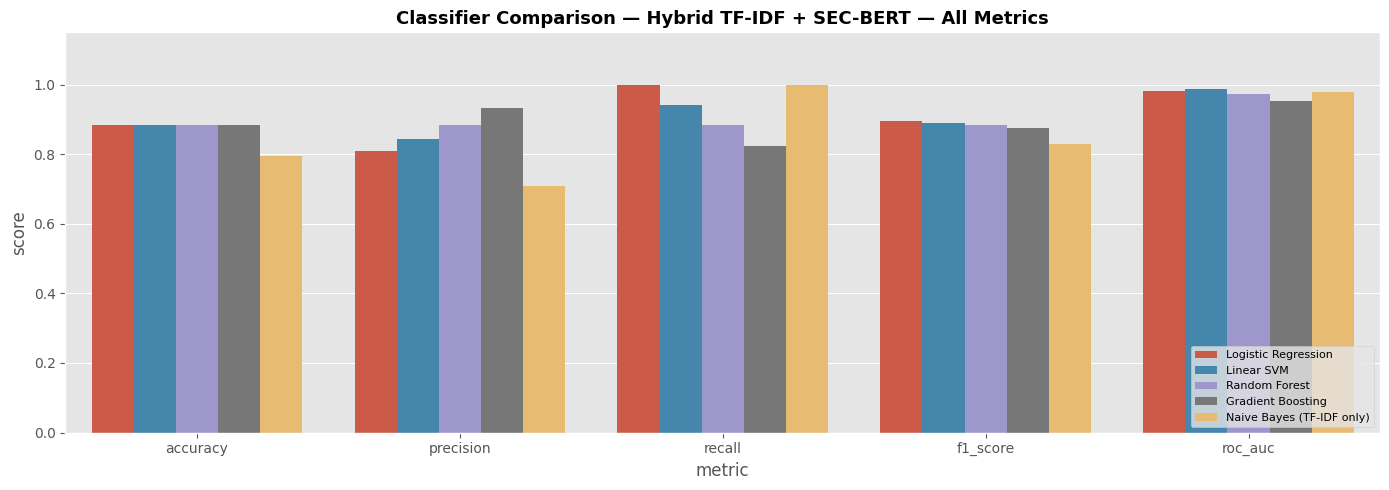

In [8]:
# All metrics bar chart
metrics_cols = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
melt_df = results_df.melt(id_vars="model", value_vars=metrics_cols,
                           var_name="metric", value_name="score")

plt.figure(figsize=(14, 5))
sns.barplot(data=melt_df, x="metric", y="score", hue="model")
plt.title("Classifier Comparison — Hybrid TF-IDF + SEC-BERT — All Metrics",
          fontsize=13, fontweight="bold")
plt.ylim(0, 1.15)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

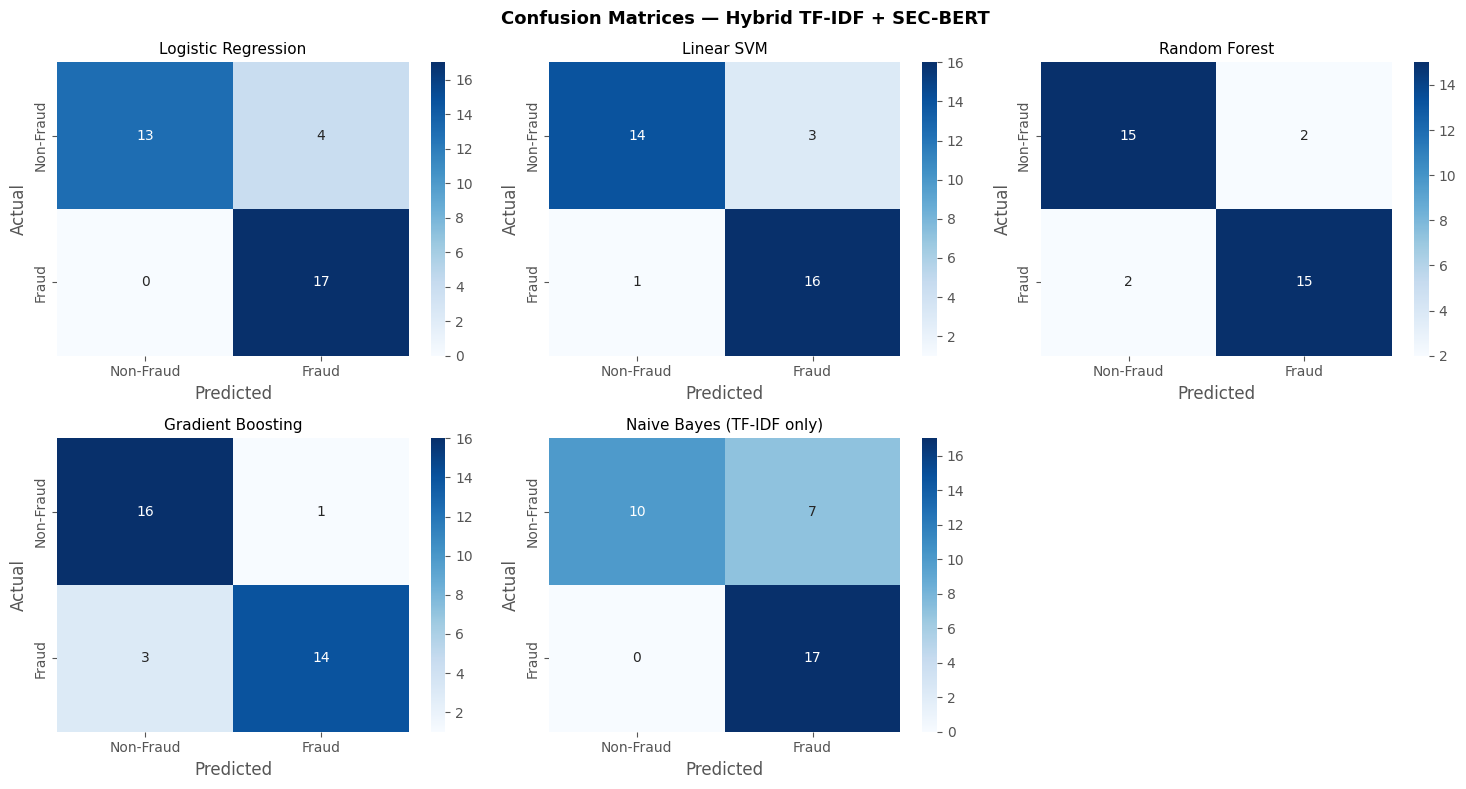

In [9]:
# Confusion matrices
n = len(results_df)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, model_name in enumerate(results_df["model"]):
    plot_confusion(y_test, predictions[model_name], model_name, axes[i])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — Hybrid TF-IDF + SEC-BERT",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

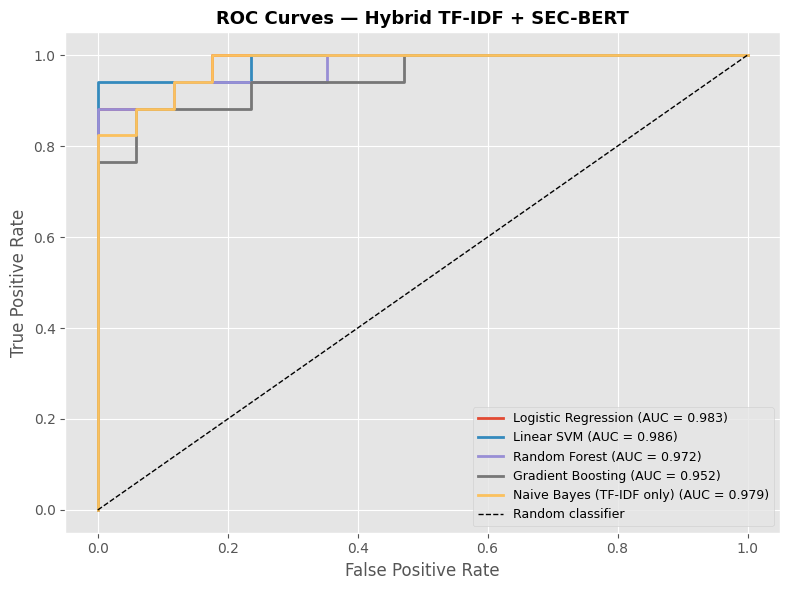

In [10]:
# ROC curves
plt.figure(figsize=(8, 6))

for name in results_df["model"]:
    proba = probabilities[name]
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Hybrid TF-IDF + SEC-BERT", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Cross-validation — robustness check

5-fold stratified CV on hybrid features. Naive Bayes is excluded from CV (different feature space).

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

print("5-Fold CV on Hybrid TF-IDF + SEC-BERT features:")
print("-" * 55)

# Only the 4 hybrid-compatible models
for name, model in hybrid_models.items():
    scores = cross_val_score(model, X_full_hybrid, y, cv=cv, scoring="f1")
    cv_results.append({
        "model"        : name,
        "cv_f1_mean"   : scores.mean(),
        "cv_f1_std"    : scores.std(),
        "cv_f1_scores" : scores.round(3).tolist()
    })
    print(f"{name:25s}: CV F1 = {scores.mean():.4f} ± {scores.std():.4f}  | folds: {scores.round(3).tolist()}")

cv_df = pd.DataFrame(cv_results).sort_values("cv_f1_mean", ascending=False)
print()
display(cv_df[["model", "cv_f1_mean", "cv_f1_std"]].round(4))

5-Fold CV on Hybrid TF-IDF + SEC-BERT features:
-------------------------------------------------------
Logistic Regression      : CV F1 = 0.8561 ± 0.0563  | folds: [0.872, 0.919, 0.8, 0.909, 0.78]
Linear SVM               : CV F1 = 0.8749 ± 0.0276  | folds: [0.865, 0.919, 0.882, 0.875, 0.833]
Random Forest            : CV F1 = 0.8968 ± 0.0564  | folds: [0.971, 0.944, 0.882, 0.875, 0.811]
Gradient Boosting        : CV F1 = 0.8139 ± 0.0758  | folds: [0.889, 0.919, 0.727, 0.778, 0.757]



,model,cv_f1_mean,cv_f1_std
2,Random Forest,0.8968,0.0564
1,Linear SVM,0.8749,0.0276
0,Logistic Regression,0.8561,0.0563
3,Gradient Boosting,0.8139,0.0758


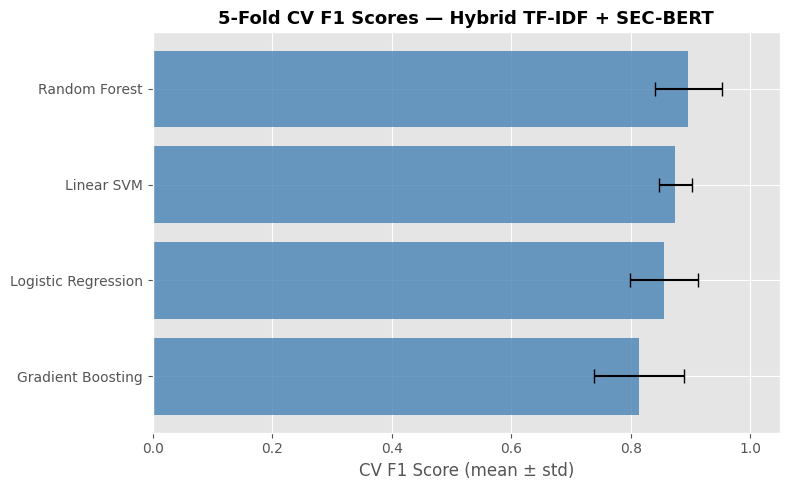

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(
    cv_df["model"],
    cv_df["cv_f1_mean"],
    xerr=cv_df["cv_f1_std"],
    color="steelblue",
    alpha=0.8,
    capsize=5
)
plt.xlabel("CV F1 Score (mean ± std)")
plt.title("5-Fold CV F1 Scores — Hybrid TF-IDF + SEC-BERT",
          fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 7. Select the final model

Selection criteria (fraud detection priorities):
- **Recall** first — missing a fraud is more costly than a false alarm
- **F1** — balance between precision and recall  
- **CV stability** (low std) — especially important on 170 samples

Selected model : Logistic Regression
Embedding      : Hybrid TF-IDF + SEC-BERT

Final performance on test set:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.76      0.87        17
       Fraud       0.81      1.00      0.89        17

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.88        34
weighted avg       0.90      0.88      0.88        34



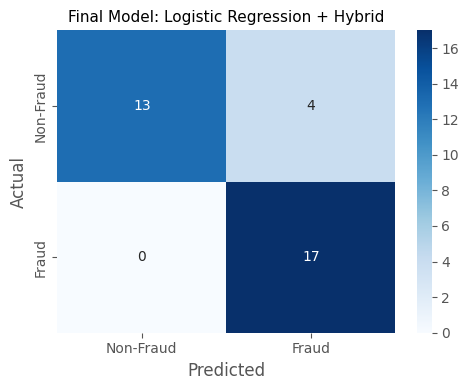

In [12]:
# Select best from the 4 hybrid-compatible models (exclude Naive Bayes)
hybrid_results_df = results_df[~results_df["model"].str.contains("Naive")].reset_index(drop=True)
best_model_name   = hybrid_results_df.iloc[0]["model"]
best_model        = trained_models[best_model_name]

print(f"Selected model : {best_model_name}")
print(f"Embedding      : Hybrid TF-IDF + SEC-BERT")
print()
print("Final performance on test set:")
print(classification_report(y_test, predictions[best_model_name],
                             target_names=["Non-Fraud", "Fraud"]))

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test, predictions[best_model_name],
               f"Final Model: {best_model_name} + Hybrid", ax)
plt.tight_layout()
plt.show()

## 8. Overfitting check

In [13]:
overfit_results = []

for name, model in hybrid_models.items():
    y_train_pred = model.predict(X_train_hybrid)
    y_test_pred  = predictions[name]
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    test_f1  = f1_score(y_test,  y_test_pred,  zero_division=0)
    overfit_results.append({
        "model"   : name,
        "train_f1": train_f1,
        "test_f1" : test_f1,
        "gap"     : train_f1 - test_f1
    })

overfit_df = pd.DataFrame(overfit_results).sort_values("gap", ascending=False)
print("Overfitting check (Train F1 vs Test F1 gap):")
display(overfit_df.round(4))

Overfitting check (Train F1 vs Test F1 gap):


,model,train_f1,test_f1,gap
3,Gradient Boosting,1.0000,0.8750,0.1250
2,Random Forest,1.0000,0.8824,0.1176
1,Linear SVM,0.9710,0.8889,0.0821
0,Logistic Regression,0.8951,0.8947,0.0004


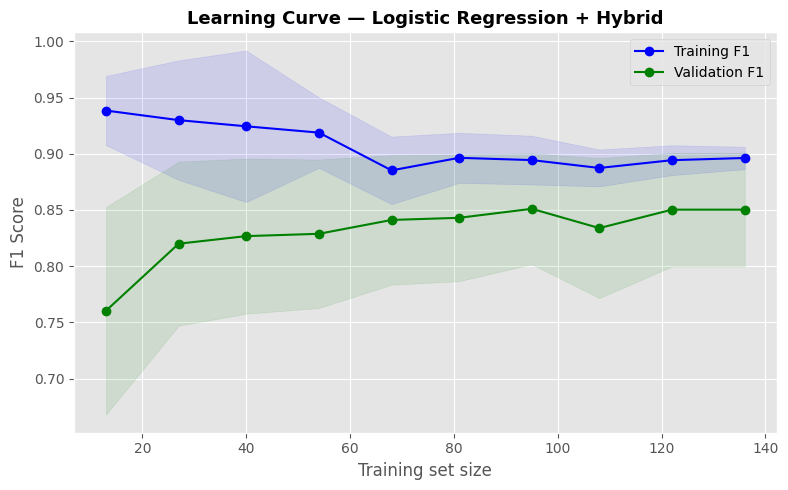

In [14]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5, scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=RANDOM_STATE
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, "o-", color="blue",  label="Training F1")
    plt.plot(train_sizes, val_mean,   "o-", color="green", label="Validation F1")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.1, color="blue")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.1, color="green")
    plt.title(f"Learning Curve — {title}", fontsize=13, fontweight="bold")
    plt.xlabel("Training set size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curve(best_model, X_full_hybrid, y, f"{best_model_name} + Hybrid")

## 9. Sample predictions

In [15]:
sample_texts  = X_test_text.iloc[:5].tolist()
true_labels   = y_test.iloc[:5].tolist()
sample_hybrid = X_test_hybrid[:5]

sample_preds = best_model.predict(sample_hybrid)
sample_proba = best_model.predict_proba(sample_hybrid)[:, 1] \
               if hasattr(best_model, "predict_proba") \
               else [None] * 5

pd.DataFrame({
    "text_preview"     : [t[:100] + "..." for t in sample_texts],
    "true_label"       : ["Fraud" if l == 1 else "Non-Fraud" for l in true_labels],
    "predicted_label"  : ["Fraud" if p == 1 else "Non-Fraud" for p in sample_preds],
    "fraud_probability": [round(p, 3) if p is not None else "N/A" for p in sample_proba],
    "correct"          : ["✓" if t == p else "✗" for t, p in zip(true_labels, sample_preds)]
})

,text_preview,true_label,predicted_label,fraud_probability,correct
0,item principal accountant fees services inform...,Non-Fraud,Non-Fraud,0.421,✓
1,item exhibits financial statement schedules re...,Fraud,Fraud,0.710,✓
2,item exhibits financial statement schedules re...,Fraud,Fraud,0.792,✓
3,item principal accounting fees services omitte...,Non-Fraud,Non-Fraud,0.174,✓
4,item principal accountant fees services inform...,Non-Fraud,Fraud,0.507,✗


## 10. Save the final model

In [ ]:
# Save best classifier
joblib.dump(best_model, "fraud_detection_final_model.pkl")
print("Saved: fraud_detection_final_model.pkl")

# Save TF-IDF vectorizer (needed at inference time)
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
print("Saved: tfidf_vectorizer.pkl")

# Save SEC-BERT embeddings for the test set (optional, for reproducibility)
np.save("X_test_secbert.npy",  X_test_secbert)
np.save("X_train_secbert.npy", X_train_secbert)
np.save("X_full_secbert.npy",  X_full_secbert)
print("Saved: SEC-BERT embedding arrays")

# Save metadata
best_row = hybrid_results_df.iloc[0]
cv_best  = cv_df[cv_df["model"] == best_model_name].iloc[0] if best_model_name in cv_df["model"].values else {}

metadata = {
    "model_name"    : best_model_name,
    "embedding"     : "Hybrid TF-IDF + SEC-BERT",
    "tfidf_features": TFIDF_FEATURES,
    "secbert_model" : SEC_BERT_MODEL,
    "test_f1"       : round(best_row["f1_score"], 4),
    "test_recall"   : round(best_row["recall"], 4),
    "test_roc_auc"  : round(best_row["roc_auc"], 4),
    "cv_f1_mean"    : round(cv_best.get("cv_f1_mean", 0), 4),
    "cv_f1_std"     : round(cv_best.get("cv_f1_std", 0), 4),
    "train_size"    : len(X_train_text),
    "test_size"     : len(X_test_text)
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: model_metadata.json")
print()
print(json.dumps(metadata, indent=2))

In [19]:
model = joblib.load("fraud_detection_final_model.pkl")
print(model.coef_.shape)  # must be (1, 1268)

(1, 1268)


## 11. Final Conclusions

### Project summary

This notebook completes the classifier comparison using the **Hybrid TF-IDF + SEC-BERT** embedding — the top-performing representation from Notebook 02 (CV F1 = 0.845, Recall = 0.929).

### Pipeline recap

| Step | Description |
|------|-------------|
| **Notebook 01** | EDA: class distribution, text length, vocabulary differences |
| **Notebook 02** | Embedding comparison: TF-IDF / SEC-BERT / FinBERT / Hybrid / Isolation Forest |
| **Notebook 02v2** | Winner: Hybrid TF-IDF + SEC-BERT (CV F1=0.845, Recall=0.929) |
| **Notebook 03** | Classifier comparison on TF-IDF (baseline) |
| **This notebook** | Classifier comparison on Hybrid → final model selection |

### Why Hybrid wins on this dataset
- **TF-IDF** captures specific fraud keyword patterns ("restatement", "going concern", "material weakness")
- **SEC-BERT** understands the contextual language of SEC filings specifically
- Combining both gives the model both lexical and semantic signals
- At 170 samples, neither alone generalises as well as their combination

### Naive Bayes caveat
Naive Bayes was evaluated on TF-IDF features only due to its non-negative sparse input constraint. Its results are not directly comparable to the other models in this notebook.

### Deployment note
Inference requires both `tfidf_vectorizer.pkl` and a running SEC-BERT model to build features before calling `fraud_detection_final_model.pkl`.